CH1: Exploratory Data Analysis</br>
<b>1. Location Estimates of Population Murder rates </b>


In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import wquantiles
import matplotlib.pyplot as plt
import os

In [2]:
print(os.getcwd())
print(os.listdir('.')) 

/workspaces/practical-Statistics-for-data-Scientists/ch1: exploratory data analysis 
['eda.ipynb']


Compute the mean, trimmed mean, and median for the population

In [3]:
state = pd.read_csv('../Datasets/state.csv')
print(state.head())
print("population mean is", state["Population"].mean())
print("trimmed mean is", stats.trim_mean(state["Population"], 0.1))
print("median is", state["Population"].median())


        State  Population  Murder.Rate Abbreviation
0     Alabama     4779736          5.7           AL
1      Alaska      710231          5.6           AK
2     Arizona     6392017          4.7           AZ
3    Arkansas     2915918          5.6           AR
4  California    37253956          4.4           CA
population mean is 6162876.3
trimmed mean is 4783697.125
median is 4436369.5


calculating weighed mean and median cause average murder rate is dependednt on population differences in each state 

In [4]:
print("weighted mean =", np.average(state["Murder.Rate"],weights=state["Population"])) 
print("weighted median =", wquantiles.median(state["Murder.Rate"],weights=state["Population"]))    

weighted mean = 4.445833981123393
weighted median = 4.4


In [5]:
print("Population standard deviation =" , state['Population'].std())
print("Population IQR =", state["Population"].quantile(0.75) - state["Population"].quantile(0.25)   )
print("Population MAD =" , stats.median_abs_deviation(state["Population"]))

Population standard deviation = 6848235.347401142
Population IQR = 4847308.0
Population MAD = 2596702.0


In [6]:
state['Murder.Rate'].quantile([0.05,0.25,0.5,0.75,0.95])

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64

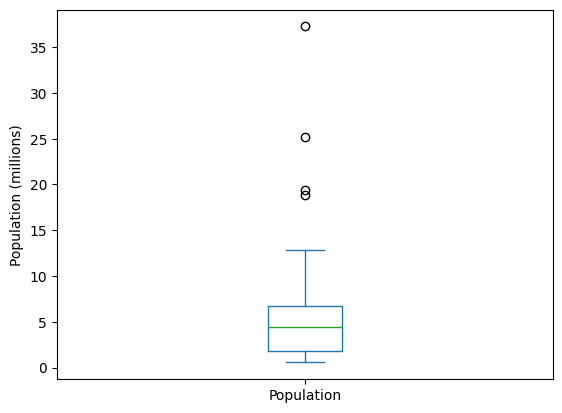

In [7]:
ax = (state['Population']/1000000).plot.box()
ax.set_ylabel('Population (millions)')
plt.show()
#we see that most of the population lie between 2 - 7 million with median being 5 mil at q2(sorted data)

Text(0.5, 0, 'Population (millions)')

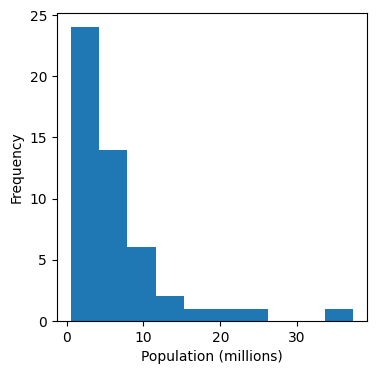

In [9]:
ax = (state['Population']/1000000).plot.hist(figsize=(4,4))
ax.set_xlabel("Population (millions)")

Text(0, 0.5, 'Density')

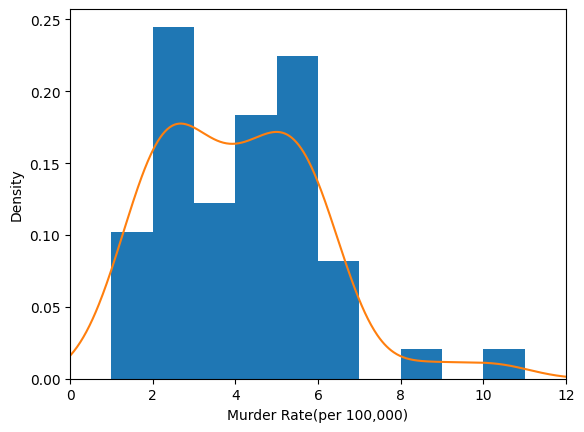

In [10]:
ax=state['Murder.Rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
state['Murder.Rate'].plot.density(ax = ax)
ax.set_xlabel("Murder Rate(per 100,000)")
ax.set_ylabel("Density")